In [1]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 72.0 MB/s  0:00:00
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------------------------------- 3.8/3.8 MB 75.6 MB/s  0:00:00
   ---------------------------------------- 0.0/801.4 kB ? eta -:--:--
   ---------------------------------------- 801.4/801.4 kB 33.7 MB/s  0:00:00
Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------------------------------------- 4.9/4.9 MB 98.3 MB/s  0:00:00

   ----------------------------------------  0/36 [pyyaml]
   - --------------------------------------  1/36 [pyasn1]
   - --------------------------------------  1/36 [pyasn1]
   -- -------------------------------------  2/36 [protobuf]
   -- -------------------------------------  2/36 [p

In [12]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs

df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')

# 3. Filter for ISOLATED Greenhouse Gas Effects
# We use experiment_id='hist-GHG' to remove non-GHG factors
df_ghg_only = df.query("experiment_id == 'hist-GHG' & table_id == 'Amon' & variable_id == 'tas' & institution_id == 'NCAR'")

# 4. Load Data
gcs = gcsfs.GCSFileSystem(token='anon')
zstore = df_ghg_only.iloc[0].zstore # Pulling the first NCAR GHG-only store[cite: 4]
ds = xr.open_zarr(gcs.get_mapper(zstore), consolidated=True)

# Example: Plotting the first time step of the temperature data
# ds.tas.isel(time=0).plot()

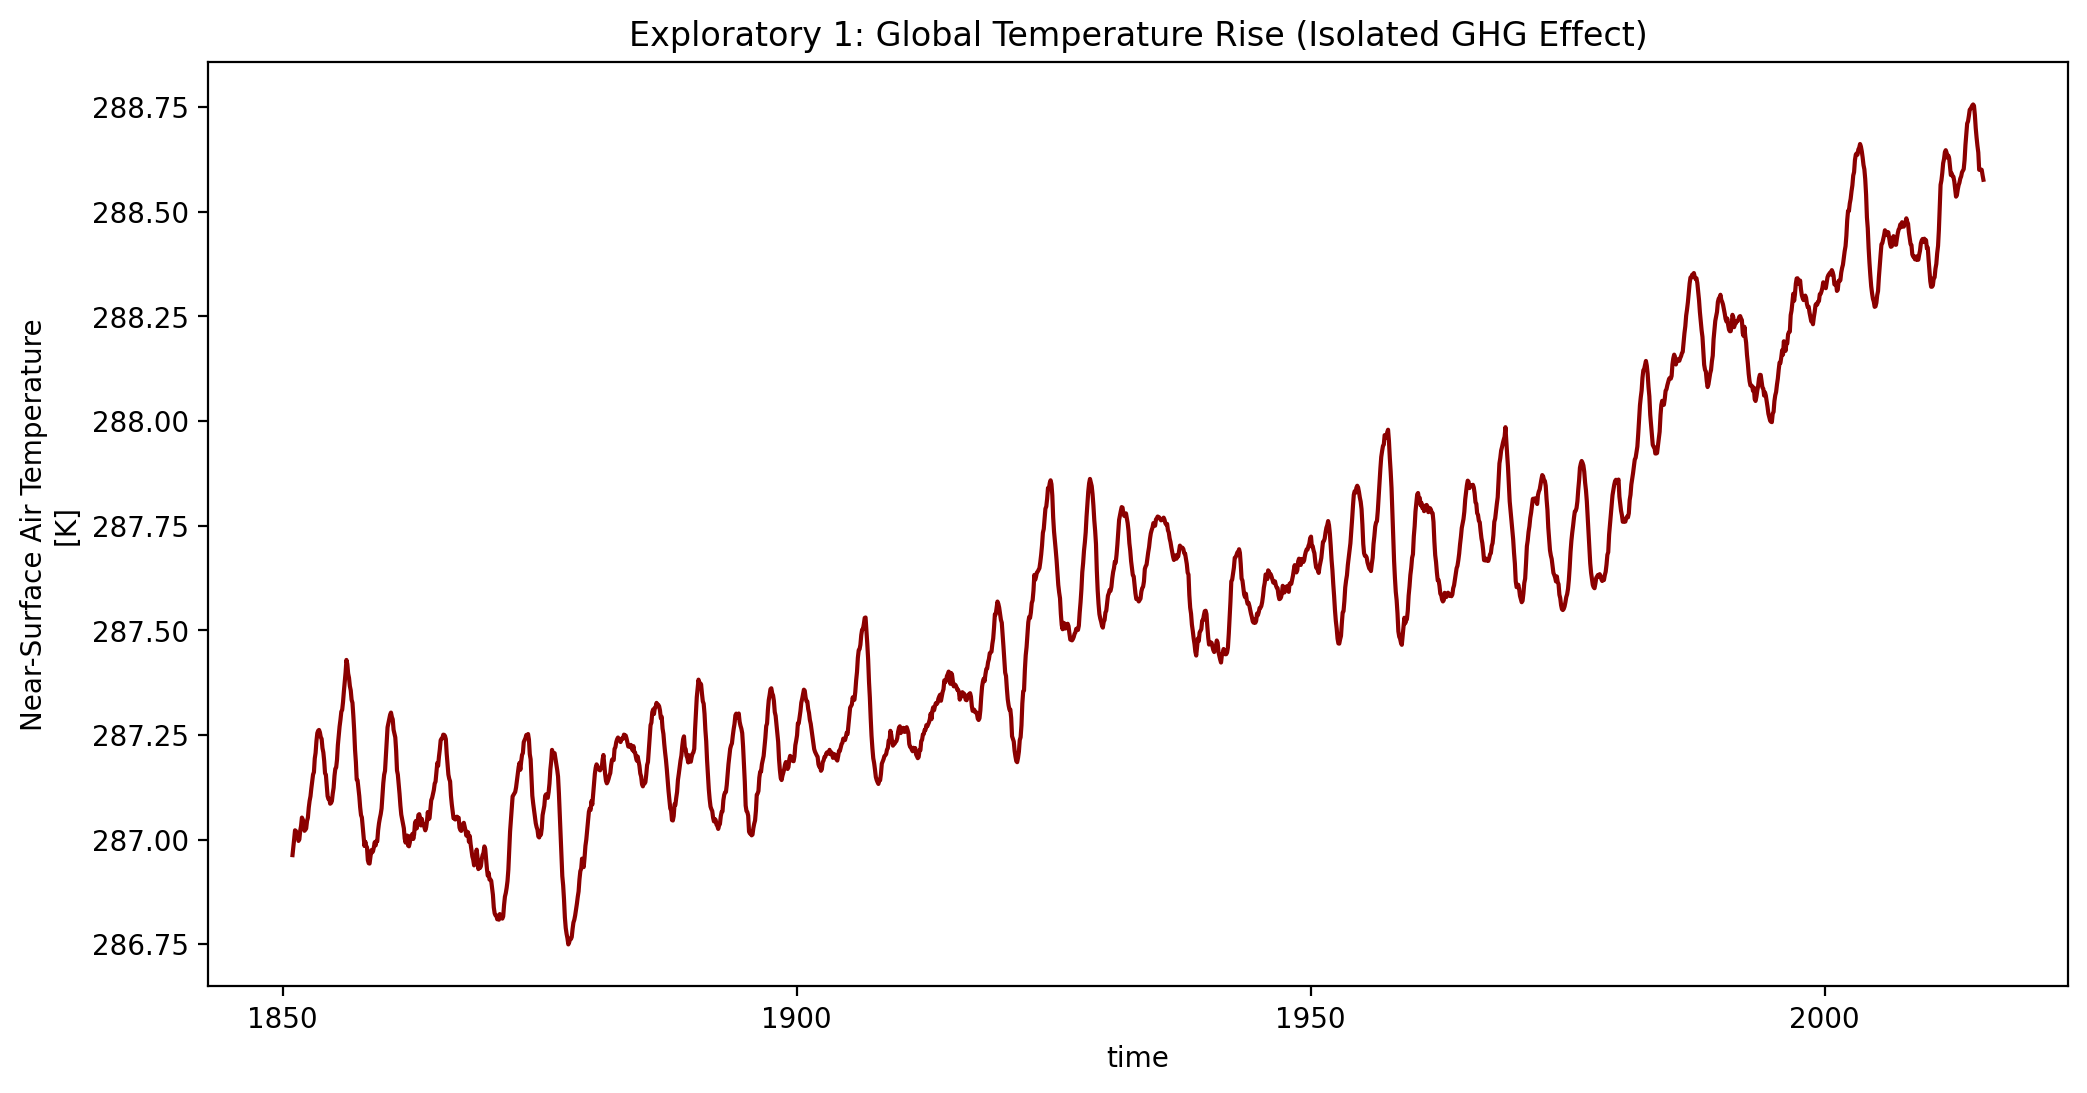

In [13]:
weights = np.cos(np.deg2rad(ds.lat))
ghg_ts = ds.tas.weighted(weights).mean(dim=['lat', 'lon'])
ghg_ts.rolling(time=12).mean().plot(color='darkred')
plt.title("Exploratory 1: Global Temperature Rise (Isolated GHG Effect)")
plt.show()



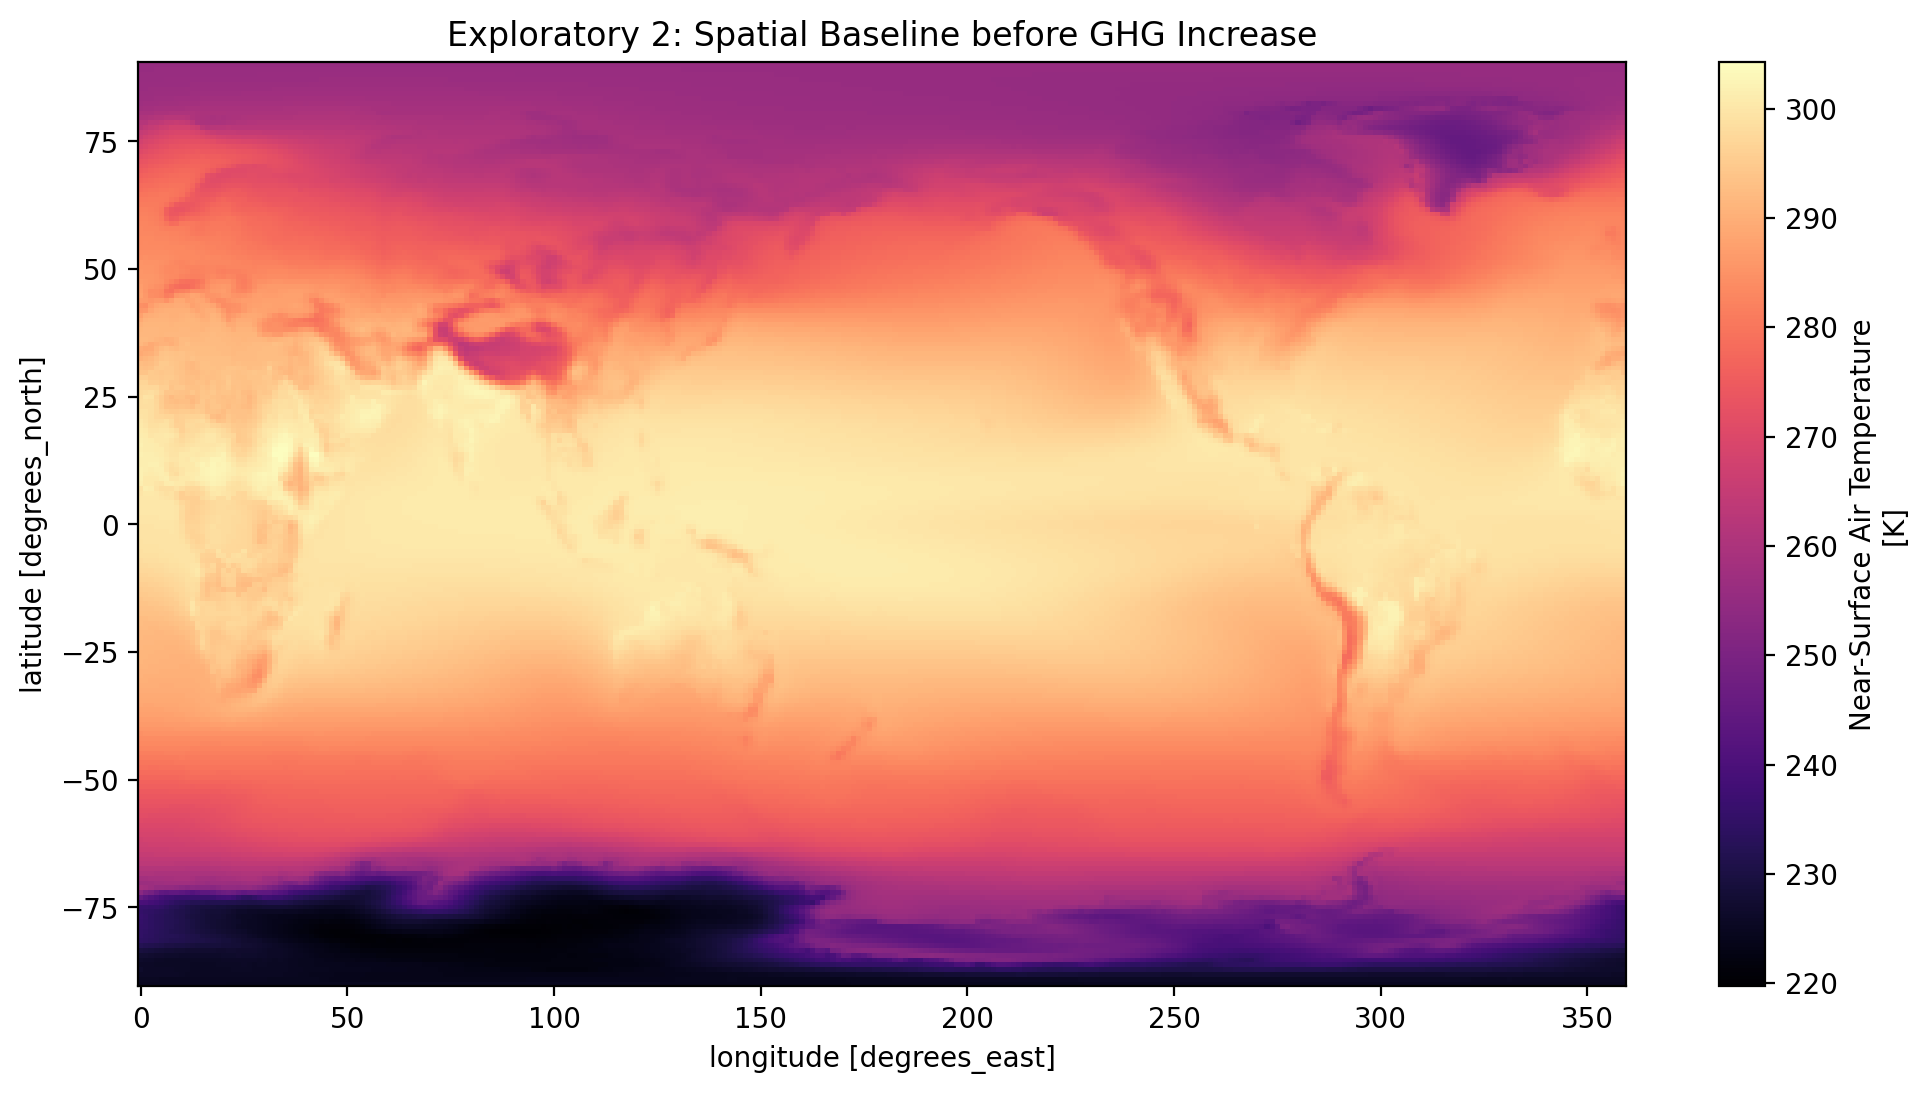

In [14]:
baseline = ds.tas.sel(time=slice("1850", "1880")).mean(dim="time")
baseline.plot(cmap='magma')
plt.title("Exploratory 2: Spatial Baseline before GHG Increase")
plt.show()

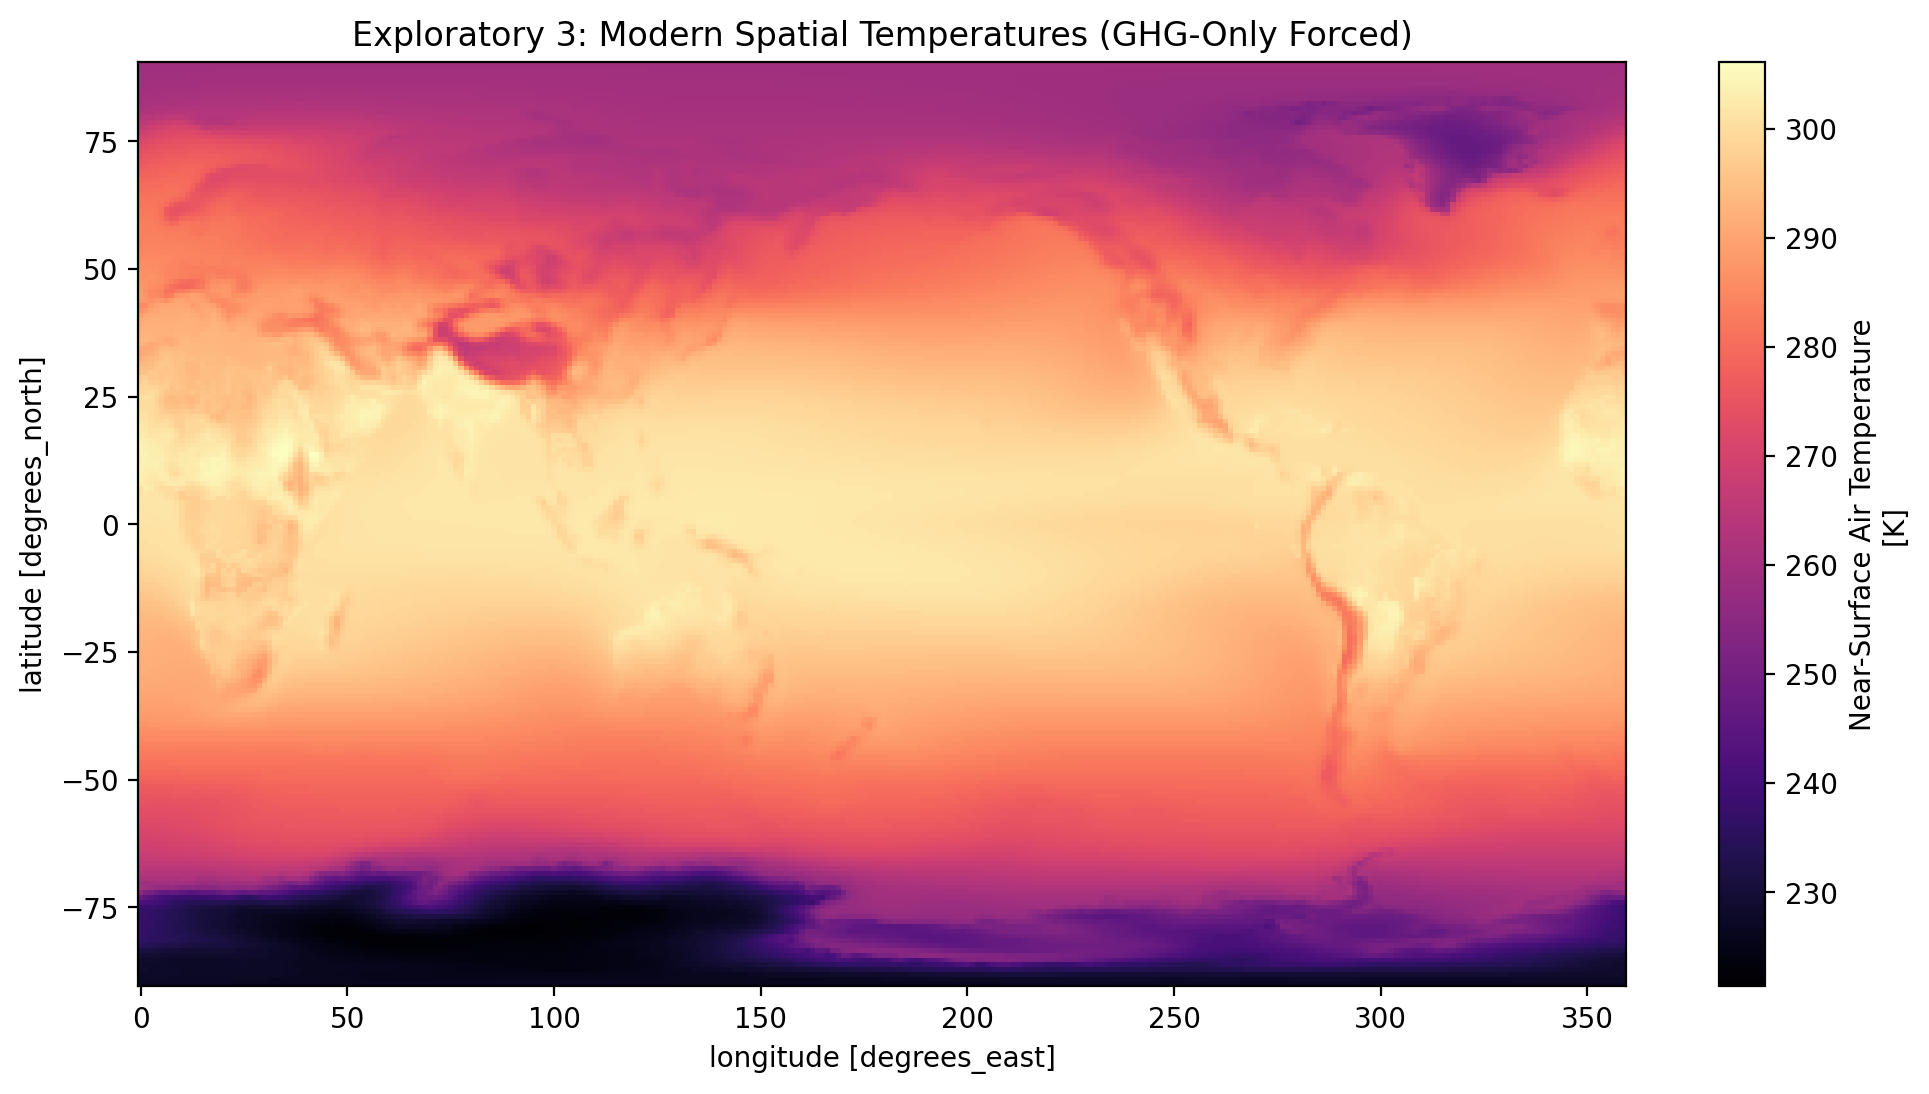

In [15]:
modern = ds.tas.sel(time=slice("2000", "2014")).mean(dim="time")
modern.plot(cmap='magma')
plt.title("Exploratory 3: Modern Spatial Temperatures (GHG-Only Forced)")
plt.show()

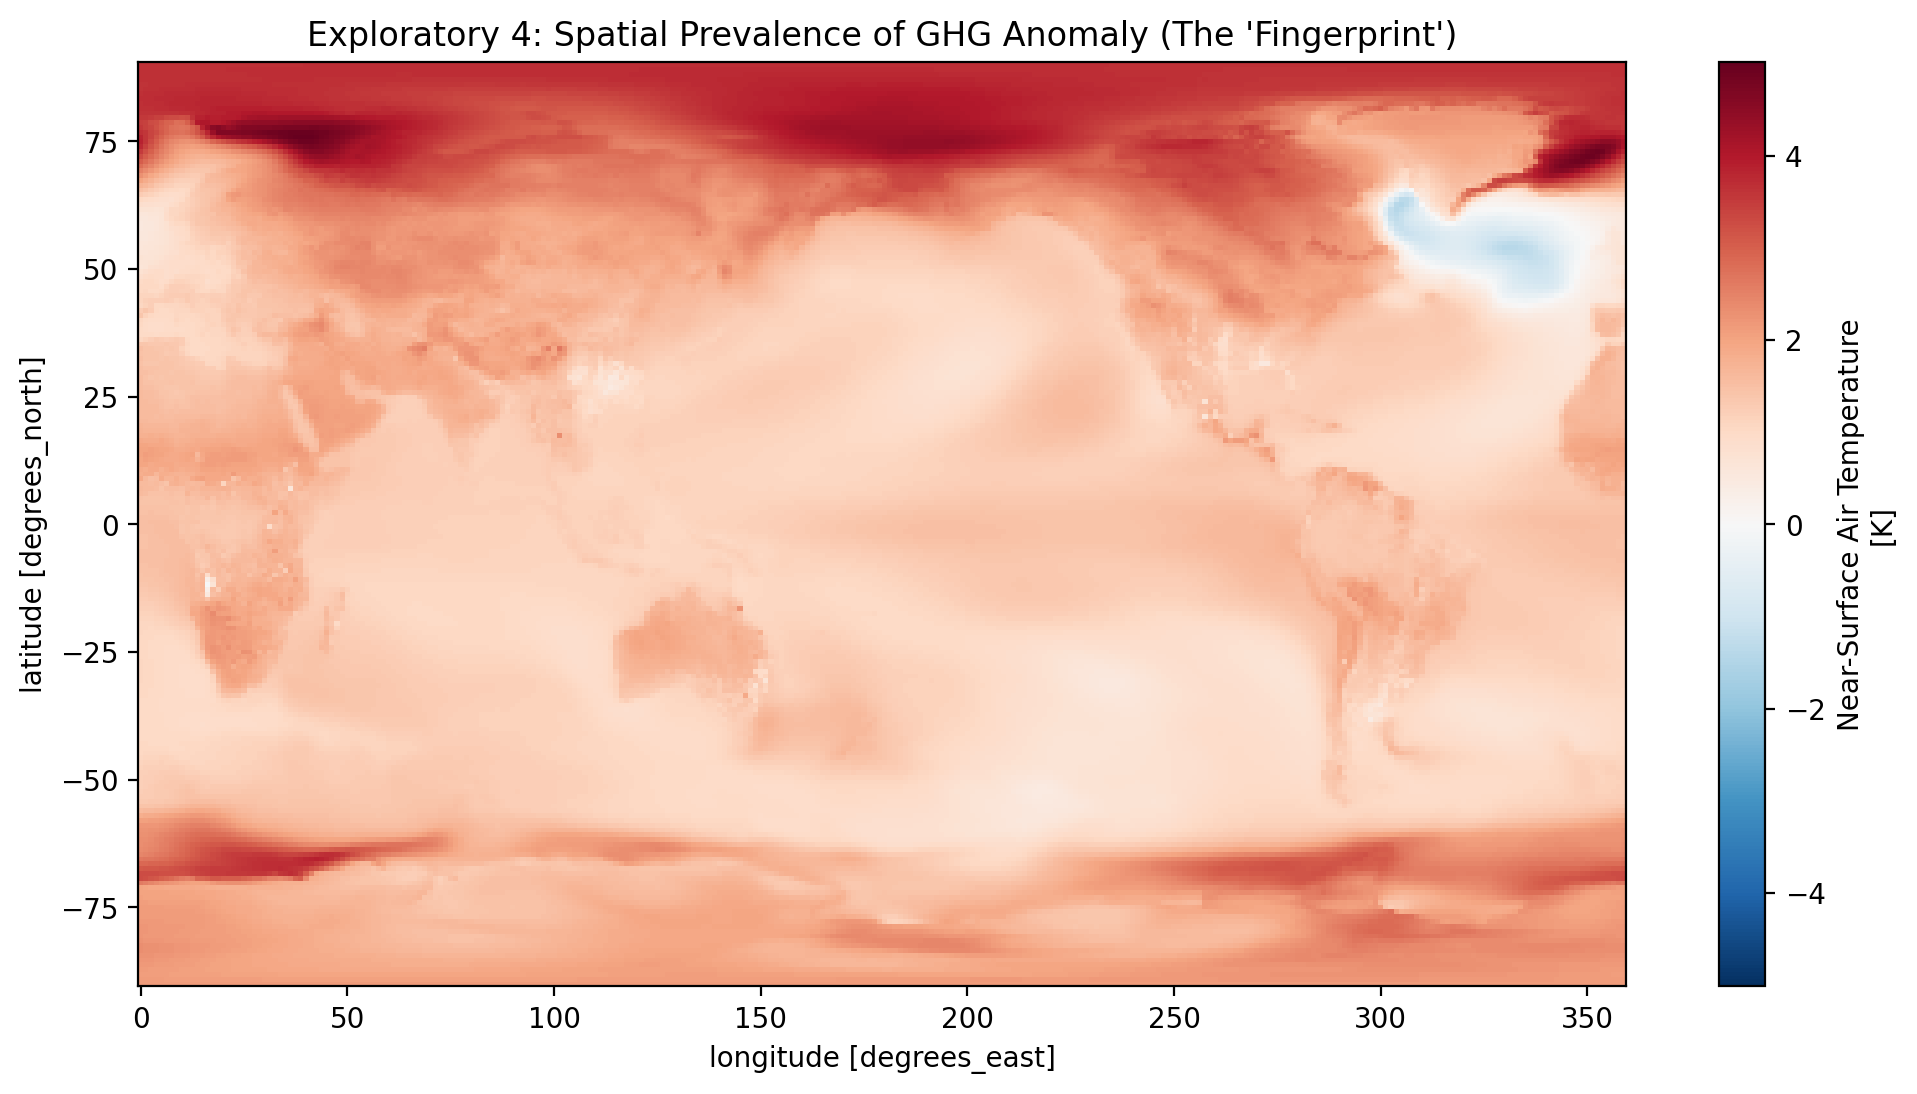

In [16]:
anomaly = modern - baseline
anomaly.plot(cmap='RdBu_r', center=0)
plt.title("Exploratory 4: Spatial Prevalence of GHG Anomaly (The 'Fingerprint')")
plt.show()

In [ ]:
anomaly.mean(dim='lon').plot()
plt.title("Exploratory 5: GHG Anomaly Prevalence by Latitude")
plt.ylabel("Temperature Change (C)")
plt.show()

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 780, plev: 19, lat: 192, lon: 288, nbnd: 2)
Coordinates:
  * time       (time) object 6kB 1950-01-15 12:00:00 ... 2014-12-15 12:00:00
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
  * lat        (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
    lat_bnds   (lat, nbnd) float32 2kB ...
    lon_bnds   (lon, nbnd) float32 2kB ...
    time_bnds  (time, nbnd) object 12kB ...
Dimensions without coordinates: nbnd
Data variables:
    co2        (time, plev, lat, lon) float32 3GB ...
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          no parent
    branch_time_in_child:   711385.0
    branch_time_in_parent:  0.0
    case_id:                14
    ...                     ...
    table_id:               Amon
    tracking_id:            hdl:21.14100

C:\Users\natha\AppData\Local\Temp\ipykernel_39680\3668867642.py:9: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\natha\AppData\Local\Temp\ipykernel_39680\3668867642.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


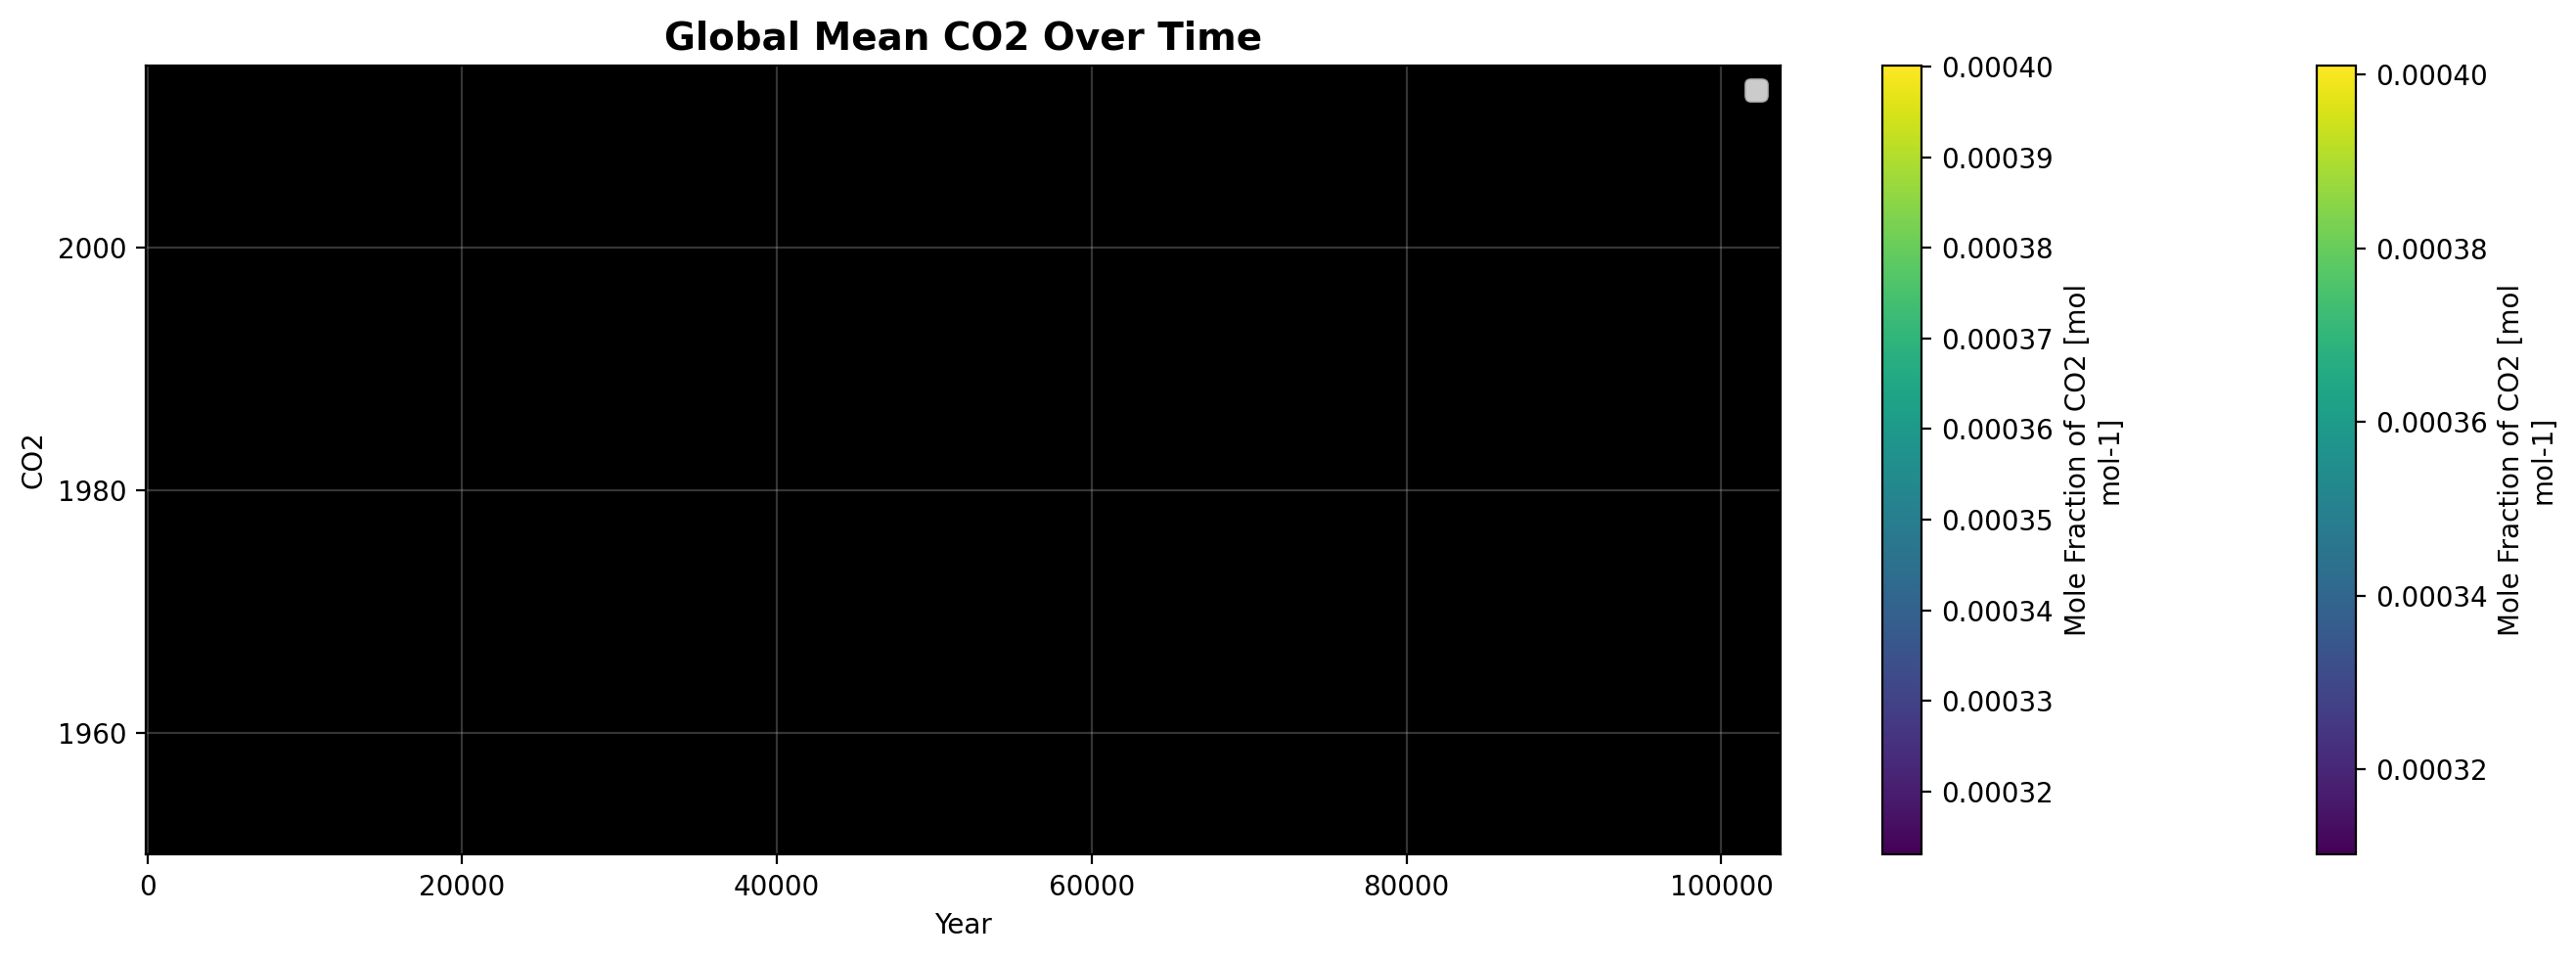

In [8]:
# ============================================
# GRAPH 1: Global Mean Time Series
# ============================================
ts_global = ds[var_id].mean(dim=['lat', 'lon']).load()

plt.figure(figsize=(14, 5))
ts_global.plot(color='#d62728', linewidth=1)
ts_global.rolling(time=12, center=True).mean().plot(color='black', linewidth=2, label='12-month rolling mean')
plt.legend()
plt.title(f'Global Mean {var_id.upper()} Over Time', fontsize=14, fontweight='bold')
plt.ylabel(var_id.upper())
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ============================================
# GRAPH 2: Spatial Map - Early Period
# ============================================
snapshot_early = ds[var_id].sel(time='1900-01', method='nearest').squeeze().load()

plt.figure(figsize=(12, 6))
snapshot_early.plot(cmap='YlOrRd', robust=True)
plt.title(f'{var_id.upper()} - January 1900', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

TypeError: '<' not supported between instances of 'str' and 'cftime._cftime.DatetimeNoLeap'